<a href="https://colab.research.google.com/github/eshan14git/football-qa-nlp/blob/eshan-dev/notebooks/05_random_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Random Forest Intent Classification

This notebook implements a Random Forest machine learning model for classifying football questions into predefined intent categories.

The model receives a natural-language football question as input and predicts its corresponding intent. It does not directly generate the final answer. The predicted intent will later be used by the Football Question Answering Assistant to retrieve the correct information from the relevant football dataset.

In [ ]:
# Data handling
import os
import pandas as pd
import numpy as np

# Model and text feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier

# Model evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Saving trained objects
import joblib

# Reproducibility
RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
# Define the main repository path
repo_path = "/content/football-qa-nlp"

# Define the folder containing the prepared intent datasets
features_path = os.path.join(repo_path, "models", "features")

# Define the output folder for trained Random Forest artifacts
random_forest_path = os.path.join(repo_path, "models", "random_forest")

# Create the Random Forest output folder if it does not already exist
os.makedirs(random_forest_path, exist_ok=True)

print("Repository path:", repo_path)
print("Feature dataset path:", features_path)
print("Random Forest output path:", random_forest_path)

Repository path: /content/football-qa-nlp
Feature dataset path: /content/football-qa-nlp/models/features
Random Forest output path: /content/football-qa-nlp/models/random_forest


In [ ]:
import os

print(os.path.exists("/content/football-qa-nlp"))

True


In [ ]:
%cd /content

# Remove the incomplete non-Git folder
!rm -rf /content/football-qa-nlp

# Clone the latest eshan-dev branch
!git clone -b eshan-dev https://github.com/eshan14git/football-qa-nlp.git

# Enter the cloned repository
%cd /content/football-qa-nlp

/content
Cloning into 'football-qa-nlp'...
remote: Enumerating objects: 182, done.
remote: Counting objects: 100% (70/70), done.
remote: Compressing objects: 100% (50/50), done.
remote: Total 182 (delta 37), reused 39 (delta 19), pack-reused 112 (from 4)
Receiving objects: 100% (182/182), 31.52 MiB | 21.92 MiB/s, done.
Resolving deltas: 100% (69/69), done.
/content/football-qa-nlp


In [ ]:
# Confirm the current Git branch
!git branch --show-current

# Display the prepared feature files
!ls -lh /content/football-qa-nlp/models/features

eshan-dev
total 58M
-rw-r--r-- 1 root root  13M Jul 30 14:55 football_corpus_clean.csv
-rw-r--r-- 1 root root  13M Jul 30 14:55 lstm_padded_sequences.npy
-rw-r--r-- 1 root root 761K Jul 30 14:55 lstm_tokenizer.pkl
-rw-r--r-- 1 root root    5 Jul 30 14:55 max_sequence_length.pkl
-rw-r--r-- 1 root root 6.9M Jul 30 14:55 question_intent_dataset.csv
-rw-r--r-- 1 root root 700K Jul 30 14:55 test_dataset.csv
-rw-r--r-- 1 root root  18M Jul 30 14:55 tfidf_features.npz
-rw-r--r-- 1 root root 194K Jul 30 14:55 tfidf_vectorizer.pkl
-rw-r--r-- 1 root root 5.5M Jul 30 14:55 train_dataset.csv
-rw-r--r-- 1 root root 699K Jul 30 14:55 validation_dataset.csv


In [ ]:
import joblib

vectorizer = joblib.load("/content/football-qa-nlp/models/features/tfidf_vectorizer.pkl")

print(vectorizer)
print("\nVocabulary size:", len(vectorizer.vocabulary_))

print("\nFirst 20 vocabulary terms:")
print(list(vectorizer.vocabulary_.keys())[:20])

TfidfVectorizer(lowercase=False, max_features=5000, min_df=2,
                ngram_range=(1, 2))

Vocabulary size: 5000

First 20 vocabulary terms:
['on', '11', '30', 'scotland', 'played', 'against', 'england', 'in', 'the', 'friendly', 'glasgow', 'final', 'score', 'was', 'and', '11 30', 'scotland played', 'played against', 'against england', 'england in']


In [ ]:
import os
import pandas as pd

# Main folder containing the intent-classification datasets
features_path = "/content/football-qa-nlp/models/features"

# Build the complete path for each dataset
train_file = os.path.join(features_path, "train_dataset.csv")
validation_file = os.path.join(features_path, "validation_dataset.csv")
test_file = os.path.join(features_path, "test_dataset.csv")

# Load the prepared datasets
train_df = pd.read_csv(train_file)
validation_df = pd.read_csv(validation_file)
test_df = pd.read_csv(test_file)

# Display their dimensions
print("Training dataset shape:", train_df.shape)
print("Validation dataset shape:", validation_df.shape)
print("Test dataset shape:", test_df.shape)

# Confirm that the total matches the complete dataset
total_records = len(train_df) + len(validation_df) + len(test_df)
print("Total records:", total_records)

Training dataset shape: (60729, 4)
Validation dataset shape: (7591, 4)
Test dataset shape: (7592, 4)
Total records: 75912


In [ ]:
# Separate input features (questions) and target labels (intents)

X_train = train_df["question"]
y_train = train_df["intent"]

X_validation = validation_df["question"]
y_validation = validation_df["intent"]

X_test = test_df["question"]
y_test = test_df["intent"]

# Display basic information
print("Training questions:", len(X_train))
print("Training labels:", len(y_train))

print("\nSample question:")
print(X_train.iloc[0])

print("\nCorresponding intent:")
print(y_train.iloc[0])

Training questions: 60729
Training labels: 60729

Sample question:
At what minute did Arthur Avom find the net against Eswatini?

Corresponding intent:
goal_minute


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create a TF-IDF vectorizer for question text
tfidf_vectorizer = TfidfVectorizer(
    lowercase=False,
    max_features=5000,
    min_df=2,
    ngram_range=(1, 2)
)

# Learn the vocabulary from the training questions and convert them into TF-IDF vectors
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

# Apply the same learned vocabulary to the validation and test questions
X_validation_tfidf = tfidf_vectorizer.transform(X_validation)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

# Display the resulting feature matrix sizes
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Validation TF-IDF shape:", X_validation_tfidf.shape)
print("Test TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (60729, 5000)
Validation TF-IDF shape: (7591, 5000)
Test TF-IDF shape: (7592, 5000)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Create the Random Forest classifier
random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Train the model using the training data
random_forest_model.fit(X_train_tfidf, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [ ]:
# Generate predictions for the validation dataset
validation_predictions = random_forest_model.predict(X_validation_tfidf)

print("Validation predictions completed.")
print("Number of predictions:", len(validation_predictions))

Validation predictions completed.
Number of predictions: 7591


In [ ]:
# Calculate evaluation metrics
accuracy = accuracy_score(y_validation, validation_predictions)
precision = precision_score(y_validation, validation_predictions, average="weighted")
recall = recall_score(y_validation, validation_predictions, average="weighted")
f1 = f1_score(y_validation, validation_predictions, average="weighted")

# Display the results
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-Score : 1.0000


In [ ]:
# Generate and display the classification report
report = classification_report(
    y_validation,
    validation_predictions
)

print(report)

                 precision    recall  f1-score   support

away_team_score       1.00      1.00      1.00       500
  first_shooter       1.00      1.00      1.00       545
    goal_minute       1.00      1.00      1.00       500
home_team_score       1.00      1.00      1.00       500
     match_date       1.00      1.00      1.00       500
 match_location       1.00      1.00      1.00       500
    match_score       1.00      1.00      1.00       500
   match_winner       1.00      1.00      1.00       500
 neutral_status       1.00      1.00      1.00       500
own_goal_status       1.00      1.00      1.00       500
 penalty_status       1.00      1.00      1.00       500
         scorer       1.00      1.00      1.00       500
shootout_winner       1.00      1.00      1.00       546
    total_goals       1.00      1.00      1.00       500
     tournament       1.00      1.00      1.00       500

       accuracy                           1.00      7591
      macro avg       1.00   

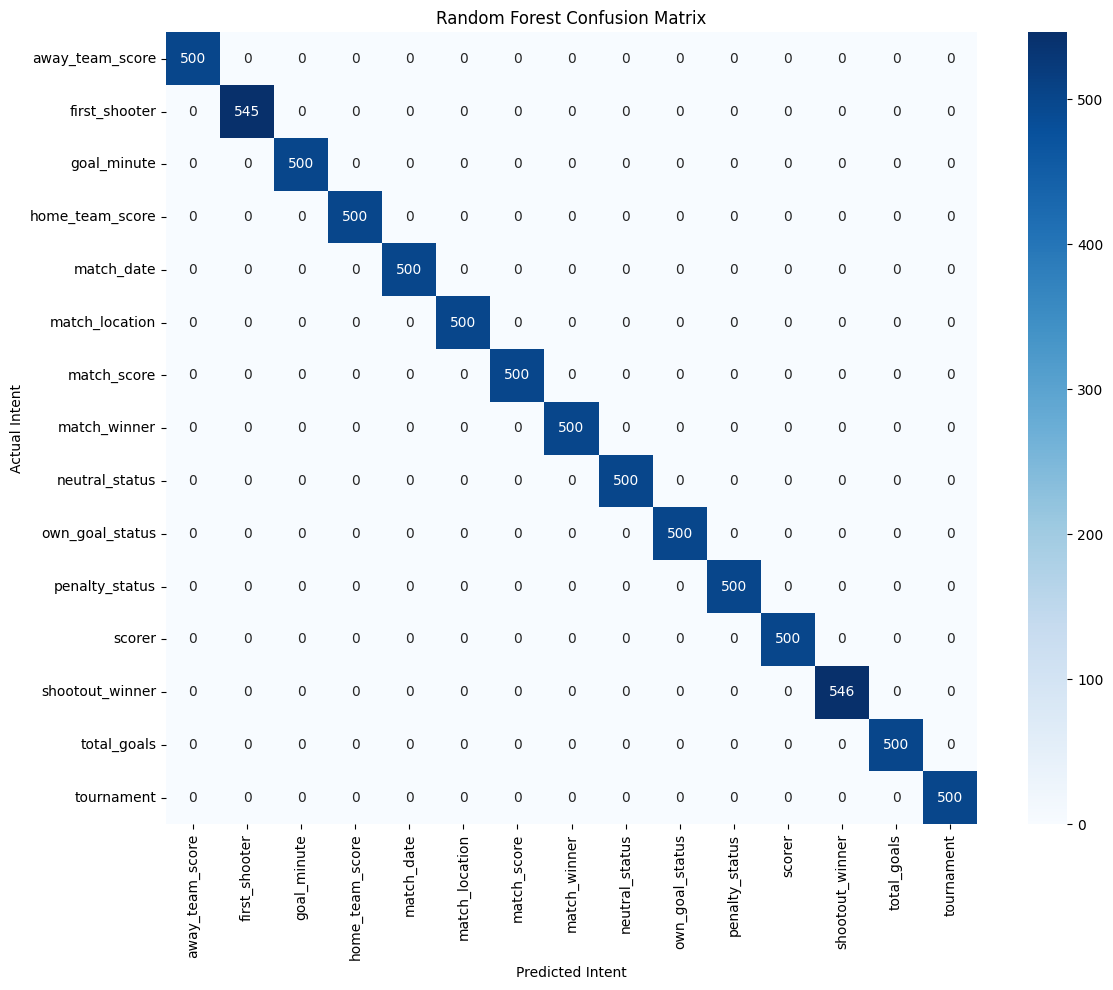

In [ ]:
# Generate the confusion matrix
cm = confusion_matrix(y_validation, validation_predictions)

# Plot the confusion matrix
plt.figure(figsize=(12, 10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=random_forest_model.classes_,
    yticklabels=random_forest_model.classes_
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Intent")
plt.ylabel("Actual Intent")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
# Predict the intents for the test dataset
test_predictions = random_forest_model.predict(X_test_tfidf)

# Calculate evaluation metrics
test_accuracy = accuracy_score(y_test, test_predictions)
test_precision = precision_score(y_test, test_predictions, average="weighted")
test_recall = recall_score(y_test, test_predictions, average="weighted")
test_f1 = f1_score(y_test, test_predictions, average="weighted")

print(f"Test Accuracy : {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall   : {test_recall:.4f}")
print(f"Test F1-Score : {test_f1:.4f}")

Test Accuracy : 1.0000
Test Precision: 1.0000
Test Recall   : 1.0000
Test F1-Score : 1.0000


In [ ]:
import os
import joblib

# Create the output directory
random_forest_path = "/content/football-qa-nlp/models/random_forest"
os.makedirs(random_forest_path, exist_ok=True)

# Save the trained Random Forest model
joblib.dump(
    random_forest_model,
    os.path.join(random_forest_path, "trained_random_forest.pkl")
)

# Save the fitted TF-IDF vectorizer
joblib.dump(
    tfidf_vectorizer,
    os.path.join(random_forest_path, "random_forest_tfidf_vectorizer.pkl")
)

print("Random Forest artifacts saved successfully.")

Random Forest artifacts saved successfully.


In [ ]:
for file in sorted(os.listdir(random_forest_path)):
    print(file)

random_forest_tfidf_vectorizer.pkl
trained_random_forest.pkl


In [2]:
import os

print("Current working directory:")
print(os.getcwd())

print("\nContents of /content:")
print(os.listdir("/content"))

Current working directory:
/content

Contents of /content:
['.config', 'sample_data']


In [3]:
import os

project_path = "/content/football-qa-nlp"

print("Does project folder exist?")
print(os.path.exists(project_path))

Does project folder exist?
False


In [1]:
!git clone -b eshan-dev https://github.com/eshan14git/football-qa-nlp.git

Cloning into 'football-qa-nlp'...
remote: Enumerating objects: 194, done.
remote: Counting objects: 100% (82/82), done.
remote: Compressing objects: 100% (60/60), done.
remote: Total 194 (delta 42), reused 46 (delta 21), pack-reused 112 (from 4)
Receiving objects: 100% (194/194), 38.19 MiB | 9.01 MiB/s, done.
Resolving deltas: 100% (74/74), done.


In [2]:
import os

print(os.listdir("/content"))

['.config', 'football-qa-nlp', 'sample_data']


In [3]:
rf_folder = "/content/football-qa-nlp/models/random_forest"

print("Folder exists:", os.path.exists(rf_folder))

if os.path.exists(rf_folder):
    print("\nFiles:")
    for f in sorted(os.listdir(rf_folder)):
        print("-", f)

Folder exists: True

Files:
- random_forest_tfidf_vectorizer.pkl
- trained_random_forest.pkl


In [5]:
import joblib
import os

rf_folder = "/content/football-qa-nlp/models/random_forest"

model_path = os.path.join(rf_folder, "trained_random_forest.pkl")
vectorizer_path = os.path.join(rf_folder, "random_forest_tfidf_vectorizer.pkl")

rf_model = joblib.load(model_path)
rf_vectorizer = joblib.load(vectorizer_path)

print("Random Forest model loaded successfully.")
print("TF-IDF vectorizer loaded successfully.")

Random Forest model loaded successfully.
TF-IDF vectorizer loaded successfully.


In [6]:
def predict_intent(question):
    question_vector = rf_vectorizer.transform([question])
    prediction = rf_model.predict(question_vector)[0]
    return prediction

test_question = "Who won the 2014 FIFA World Cup Final?"

predicted_intent = predict_intent(test_question)

print("Question:", test_question)
print("Predicted intent:", predicted_intent)

Question: Who won the 2014 FIFA World Cup Final?
Predicted intent: match_winner


In [7]:
import os

project_path = "/content/football-qa-nlp"

print("Folders/files containing CSV datasets:\n")

for root, dirs, files in os.walk(project_path):
    csv_files = [f for f in files if f.endswith(".csv")]

    if csv_files:
        print(root)
        for f in sorted(csv_files):
            print("   -", f)

Folders/files containing CSV datasets:

/content/football-qa-nlp/data
   - former_names.csv
   - former_names_clean.csv
   - goalscorers.csv
   - goalscorers_clean.csv
   - results.csv
   - results_clean.csv
   - shootouts.csv
   - shootouts_clean.csv
/content/football-qa-nlp/models/features
   - football_corpus_clean.csv
   - question_intent_dataset.csv
   - test_dataset.csv
   - train_dataset.csv
   - validation_dataset.csv


In [8]:
import pandas as pd
import os

data_path = "/content/football-qa-nlp/data"

results_df = pd.read_csv(os.path.join(data_path, "results_clean.csv"))
goalscorers_df = pd.read_csv(os.path.join(data_path, "goalscorers_clean.csv"))
shootouts_df = pd.read_csv(os.path.join(data_path, "shootouts_clean.csv"))
former_names_df = pd.read_csv(os.path.join(data_path, "former_names_clean.csv"))

print("Datasets loaded successfully.\n")

print("Results:", results_df.shape)
print("Goalscorers:", goalscorers_df.shape)
print("Shootouts:", shootouts_df.shape)
print("Former names:", former_names_df.shape)

Datasets loaded successfully.

Results: (49485, 9)
Goalscorers: (47855, 8)
Shootouts: (682, 5)
Former names: (36, 4)


In [9]:
print("RESULTS COLUMNS:")
print(results_df.columns.tolist())

print("\nGOALSCORERS COLUMNS:")
print(goalscorers_df.columns.tolist())

print("\nSHOOTOUTS COLUMNS:")
print(shootouts_df.columns.tolist())

print("\nFORMER NAMES COLUMNS:")
print(former_names_df.columns.tolist())

RESULTS COLUMNS:
['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'city', 'country', 'neutral']

GOALSCORERS COLUMNS:
['date', 'home_team', 'away_team', 'team', 'scorer', 'minute', 'own_goal', 'penalty']

SHOOTOUTS COLUMNS:
['date', 'home_team', 'away_team', 'winner', 'first_shooter']

FORMER NAMES COLUMNS:
['current', 'former', 'start_date', 'end_date']


In [10]:
world_cup_2014 = results_df[
    (results_df["date"].str.startswith("2014")) &
    (results_df["tournament"].str.contains("FIFA World Cup", case=False, na=False))
]

print("Number of 2014 World Cup matches:", len(world_cup_2014))

display(
    world_cup_2014[
        ["date", "home_team", "away_team", "home_score", "away_score", "tournament"]
    ].tail(10)
)

Number of 2014 World Cup matches: 64


,date,home_team,away_team,home_score,away_score,tournament
37920,2014-07-01,Argentina,Switzerland,1,0,FIFA World Cup
37921,2014-07-01,Belgium,United States,2,1,FIFA World Cup
37923,2014-07-04,Brazil,Colombia,2,1,FIFA World Cup
37924,2014-07-04,France,Germany,0,1,FIFA World Cup
37925,2014-07-05,Argentina,Belgium,1,0,FIFA World Cup
37926,2014-07-05,Netherlands,Costa Rica,0,0,FIFA World Cup
37928,2014-07-08,Brazil,Germany,1,7,FIFA World Cup
37929,2014-07-09,Netherlands,Argentina,0,0,FIFA World Cup
37931,2014-07-12,Brazil,Netherlands,0,3,FIFA World Cup
37933,2014-07-13,Germany,Argentina,1,0,FIFA World Cup


In [11]:
def answer_match_winner(question):
    # Extract a 4-digit year from the question
    import re

    year_match = re.search(r"\b(19|20)\d{2}\b", question)

    if not year_match:
        return "I couldn't identify the year from the question."

    year = year_match.group()

    # For now, handle FIFA World Cup questions
    if "world cup" in question.lower():
        matches = results_df[
            (results_df["date"].str.startswith(year)) &
            (results_df["tournament"].str.contains("FIFA World Cup", case=False, na=False))
        ].sort_values("date")

        if matches.empty:
            return f"I couldn't find FIFA World Cup matches for {year}."

        # Final match = last match in that tournament/year
        final_match = matches.iloc[-1]

        home_team = final_match["home_team"]
        away_team = final_match["away_team"]
        home_score = final_match["home_score"]
        away_score = final_match["away_score"]

        if home_score > away_score:
            winner = home_team
        elif away_score > home_score:
            winner = away_team
        else:
            return (
                f"The match between {home_team} and {away_team} ended "
                f"{home_score}-{away_score}. A shootout may need to be checked."
            )

        return (
            f"{winner} won the {year} FIFA World Cup Final, "
            f"defeating {away_team if winner == home_team else home_team} "
            f"{home_score}-{away_score}."
        )

    return "I can currently answer FIFA World Cup winner questions only."

In [12]:
question = "Who won the 2014 FIFA World Cup Final?"

predicted_intent = predict_intent(question)

print("Question:", question)
print("Predicted intent:", predicted_intent)

if predicted_intent == "match_winner":
    answer = answer_match_winner(question)
    print("Answer:", answer)
else:
    print("Answer retrieval for this intent is not implemented yet.")

Question: Who won the 2014 FIFA World Cup Final?
Predicted intent: match_winner
Answer: Germany won the 2014 FIFA World Cup Final, defeating Argentina 1-0.


In [13]:
print("Random Forest classes:\n")

for intent in rf_model.classes_:
    print("-", intent)

Random Forest classes:

- away_team_score
- first_shooter
- goal_minute
- home_team_score
- match_date
- match_location
- match_score
- match_winner
- neutral_status
- own_goal_status
- penalty_status
- scorer
- shootout_winner
- total_goals
- tournament


In [14]:
import pandas as pd
import os

features_path = "/content/football-qa-nlp/models/features"

qa_dataset = pd.read_csv(
    os.path.join(features_path, "question_intent_dataset.csv")
)

print("Columns:", qa_dataset.columns.tolist())
print("Shape:", qa_dataset.shape)

display(qa_dataset.head())

Columns: ['question', 'intent', 'answer', 'source_dataset']
Shape: (75912, 4)


,question,intent,answer,source_dataset
0,What was the home team's score in Madagascar v...,home_team_score,1,results
1,What was the final result when Curaçao played ...,match_score,Curaçao 4 - 0 Aruba,results
2,Who scored for Montenegro against Croatia?,scorer,Milutin Osmajić,goalscorers
3,How many total goals were scored between Myanm...,total_goals,1,results
4,How many goals did the home team Togo score in...,home_team_score,1,results


In [15]:
# Check how many team pairings occur more than once in results_clean.csv

pair_counts = (
    results_df
    .assign(
        team_pair=results_df.apply(
            lambda row: tuple(sorted([row["home_team"], row["away_team"]])),
            axis=1
        )
    )
    .groupby("team_pair")
    .size()
    .sort_values(ascending=False)
)

print("Team pairs that played more than once:")
print((pair_counts > 1).sum())

print("\nExamples of repeated matchups:")
display(pair_counts[pair_counts > 1].head(20))

Team pairs that played more than once:
5527

Examples of repeated matchups:


,0
team_pair,
"(Argentina, Uruguay)",183
"(Austria, Hungary)",137
"(Belgium, Netherlands)",129
"(Guernsey, Jersey)",119
"(England, Scotland)",118
"(Argentina, Brazil)",110
"(Kenya, Uganda)",110
"(Norway, Sweden)",110
"(Denmark, Sweden)",108


In [16]:
myanmar_india = results_df[
    (
        (results_df["home_team"] == "Myanmar") &
        (results_df["away_team"] == "India")
    )
    |
    (
        (results_df["home_team"] == "India") &
        (results_df["away_team"] == "Myanmar")
    )
][
    ["date", "home_team", "away_team",
     "home_score", "away_score", "tournament"]
]

display(myanmar_india)

,date,home_team,away_team,home_score,away_score,tournament
3586,1952-03-14,Myanmar,India,0,4,Friendly
3853,1953-10-31,Myanmar,India,2,4,Friendly
4039,1954-12-19,India,Myanmar,2,1,Friendly
4193,1955-12-22,Myanmar,India,1,2,Friendly
4675,1958-05-26,Myanmar,India,2,3,Asian Games
6115,1964-09-06,Myanmar,India,1,0,Merdeka Tournament
6428,1965-08-27,Myanmar,India,1,1,Merdeka Tournament
7211,1967-11-12,Myanmar,India,2,0,AFC Asian Cup qualification
7417,1968-08-17,Myanmar,India,1,3,Merdeka Tournament
7865,1969-11-02,Myanmar,India,6,0,Merdeka Tournament


In [17]:
for intent in sorted(qa_dataset["intent"].unique()):

    print("\n" + "=" * 70)
    print("INTENT:", intent)
    print("=" * 70)

    examples = qa_dataset[
        qa_dataset["intent"] == intent
    ][
        ["question", "answer", "source_dataset"]
    ].sample(
        n=min(5, len(qa_dataset[qa_dataset["intent"] == intent])),
        random_state=42
    )

    for _, row in examples.iterrows():
        print("\nQ:", row["question"])
        print("A:", row["answer"])


INTENT: away_team_score

Q: What was the away score when Ivory Coast played Egypt?
A: 4

Q: How many goals did the away team South Africa score in the African Cup of Nations qualification match against Sierra Leone?
A: 0

Q: How many goals did the away team Basque Country score in the Friendly match against Czechoslovakia?
A: 2

Q: What was the away team's score in Liberia versus Gambia?
A: 1

Q: What was the away team's score when United States played Costa Rica on 2005-07-12?
A: 0

INTENT: first_shooter

Q: Which team kicked first in the shootout between Canada and Guatemala?
A: Canada

Q: Who took the first penalty in the shootout between Lesotho and Zambia?
A: Unknown

Q: Which team kicked first in the shootout between New Zealand and Poland?
A: Unknown

Q: Who kicked first when Guatemala played Guadeloupe in a penalty shootout?
A: Guatemala

Q: Who took the first penalty in the shootout between Uruguay and Ghana?
A: Uruguay

INTENT: goal_minute

Q: In which minute did Francesco G